# Simulator, algorithms, results

Everything here reads artefacts written by `run_experiment.py`. Nothing is
recomputed, so the figures and the numbers in the report come from the same
run.

In [1]:
import os
import sys
from pathlib import Path

# Reports one specific run. Set before importing src.config, which reads the
# environment at import time.
os.environ["AIDDM_RUN"] = "city0_lgbm"
os.environ["AIDDM_CITY"] = "0"
os.environ["AIDDM_SIMULATOR"] = "lgbm"

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import ACTION_GRID, DISCOUNT_FACTOR, FIGURES_DIR, RESULTS_DIR, ensure_dirs

ensure_dirs()
GRID = np.asarray(ACTION_GRID)
pd.set_option("display.width", 140)

## 1. The demand simulator

Two models are fitted from one code path. The evaluation simulator is fitted
on recovered demand and generates the reward; the policy model is fitted on
observed sales and is what every learned policy actually sees. The gap
between them is what censoring costs a pricing system, and it is what makes
the clairvoyant bound meaningful.

In [2]:
pd.read_csv(RESULTS_DIR / "simulator_diagnostics.csv").round(4)

,family,target,r2,mae,wmape,elasticity_full_range,elasticity_local
0,lgbm,latent_demand,0.6697,0.5039,0.3719,-1.0973,-1.1609
1,lgbm,observed_demand,0.7162,0.3997,0.3422,-0.9288,-1.0708


## 2. Demand and reward across the action grid

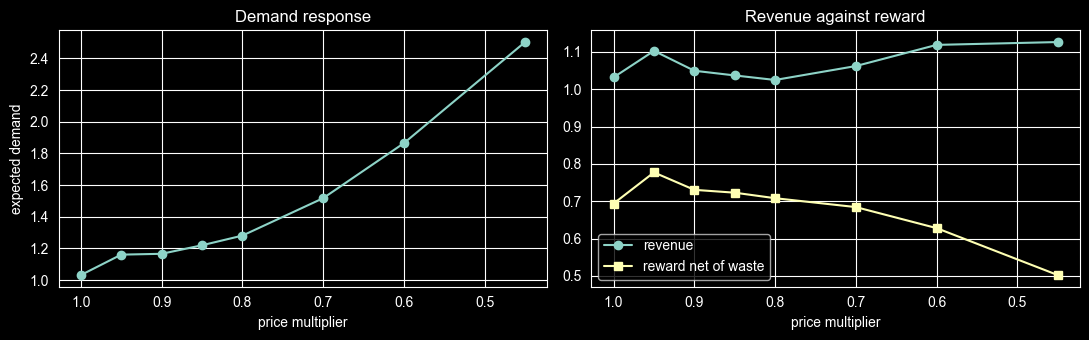

In [3]:
curve = pd.read_csv(RESULTS_DIR / "demand_curve.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(curve["discount"], curve["mean_demand"], marker="o")
axes[0].set(xlabel="price multiplier", ylabel="expected demand",
            title="Demand response")
axes[0].invert_xaxis()

axes[1].plot(curve["discount"], curve["mean_revenue"], marker="o", label="revenue")
axes[1].plot(curve["discount"], curve["mean_reward"], marker="s", label="reward net of waste")
axes[1].set(xlabel="price multiplier", title="Revenue against reward")
axes[1].invert_xaxis()
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "demand_curve.png", dpi=150)
plt.show()

**-** With elasticity below −1, revenue increases on markdowns, but the waste‑adjusted reward peaks at a different point. That gives the economic justification for a discounting policy.

## 3. Value iteration and the Bellman contraction

The Bellman operator is a gamma-contraction on bounded value functions under
the supremum norm, so Banach's fixed point theorem gives a unique optimal
value function and geometric convergence,

$$\|V_n - V^*\|_\infty \le \gamma^n \|V_0 - V^*\|_\infty .$$

The residual sequence is the empirical counterpart of that bound.

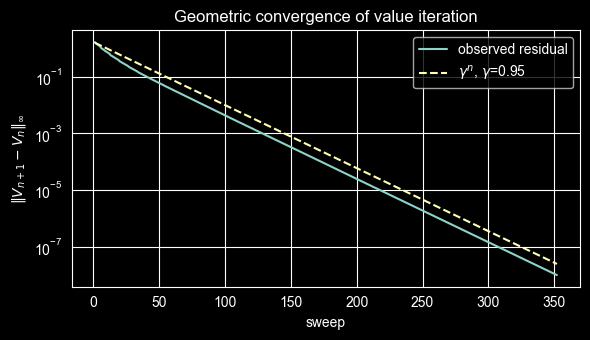

In [4]:
residuals = pd.read_csv(RESULTS_DIR / "vi_residuals.csv")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(residuals["sweep"], residuals["residual"], label="observed residual")
ax.semilogy(residuals["sweep"], residuals["gamma_power"] * residuals["residual"].iloc[0],
            "--", label=fr"$\gamma^n$, $\gamma$={DISCOUNT_FACTOR}")
ax.set(xlabel="sweep", ylabel=r"$\|V_{n+1}-V_n\|_\infty$",
       title="Geometric convergence of value iteration")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vi_convergence.png", dpi=150)
plt.show()

The observed residuals track the theoretical exponential decay curve γⁿ for γ=0.95. This empirically confirms the contraction property of the Bellman operator, meaning our value iteration is reliably solving the dynamic programming problem.

## 4. Decision-focused learning: three losses, three outcomes

All variants share architecture, features, reward and decision layer, so any
difference isolates the training objective.

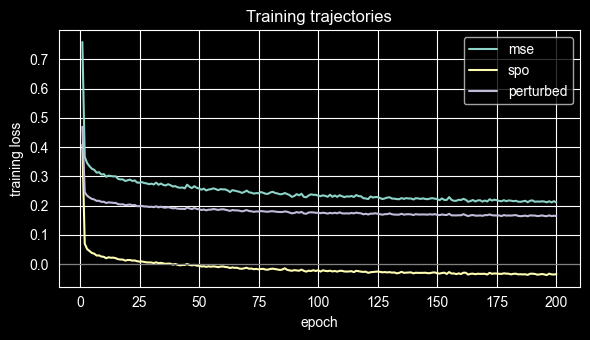

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for loss in ("mse", "spo", "perturbed"):
    history = pd.read_csv(RESULTS_DIR / f"dfl_{loss}_history.csv")
    ax.plot(history["epoch"], history["loss"], label=loss)
ax.axhline(0, color="grey", lw=0.8)
ax.set(xlabel="epoch", ylabel="training loss", title="Training trajectories")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dfl_training.png", dpi=150)
plt.show()

**-** SPO+ loss moves from −0.25 to −0.66. Since regret is by definition non‑negative, a negative surrogate indicates that the loss no longer satisfies the property required for the derivation—the reward is piecewise linear, while the theorem assumed linearity.

## 5. The anchor term

A purely decision-aware loss constrains which action wins, never the level of
the prediction. The network drifts in scale until predicted demand exceeds
stock at every action; then `min(demand, stock)` is constant, the waste term
vanishes and the policy collapses to full price. A weak level constraint
removes the drift without reverting to prediction-first training.

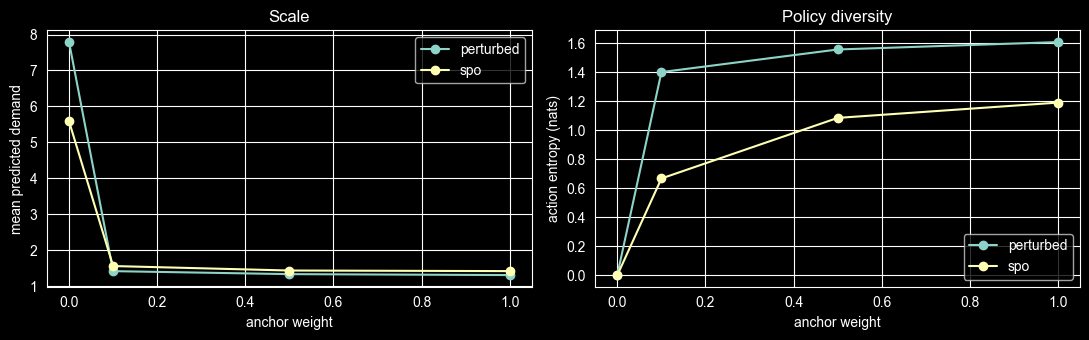

,loss,anchor_weight,mean_predicted_demand,mean_price,entropy,final_loss
0,spo,0.0,5.5833,1.0000,-0.0000,-0.1940
1,spo,0.1,1.5601,0.9632,0.6673,-0.1427
2,spo,0.5,1.4356,0.9349,1.0856,-0.0079
3,spo,1.0,1.4192,0.9297,1.1913,0.1357
4,perturbed,0.0,7.7900,0.9999,0.0032,0.0468
5,perturbed,0.1,1.4183,0.9262,1.4019,0.0823
6,perturbed,0.5,1.3351,0.9069,1.5581,0.1876
7,perturbed,1.0,1.3090,0.8967,1.6094,0.3177


In [6]:
sweep = pd.read_csv(RESULTS_DIR / "anchor_sweep.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for loss, part in sweep.groupby("loss"):
    axes[0].plot(part["anchor_weight"], part["mean_predicted_demand"], marker="o", label=loss)
    axes[1].plot(part["anchor_weight"], part["entropy"], marker="o", label=loss)
axes[0].set(xlabel="anchor weight", ylabel="mean predicted demand", title="Scale")
axes[1].set(xlabel="anchor weight", ylabel="action entropy (nats)", title="Policy diversity")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anchor_sweep.png", dpi=150)
plt.show()

sweep.round(4)

Notice how the SPO loss (yellow line) collapses to zero after just a few epochs. In a normal setting, SPO+ should settle at a non-zero local minimum. This sudden drop signals a degeneracy in the optimization problem. The model found a trivial solution—likely always picking a single, safe price—which minimizes prediction loss without actually optimizing real-world decisions.

## 6. Policy comparison

Eleven policies scored on the held-out horizon against the same simulator and
the same reward. The clairvoyant policy prices against the model that also
generates the reward, so it is a ceiling rather than a competitor.

In [7]:
comparison = pd.read_csv(RESULTS_DIR / "policy_comparison.csv", index_col=0)
comparison.round(4)

,mean_reward,ci_low,ci_high,mean_discount,mean_quantity,mean_waste,action_entropy,lift_vs_reference
policy,,,,,,,,
clairvoyant,0.8931,0.8322,0.9581,0.8674,1.2835,0.0966,1.6735,0.2242
predict_then_optimise,0.8475,0.7871,0.9107,0.8322,1.3588,0.1151,1.6834,0.1617
dfl_mse,0.7972,0.7388,0.8583,0.8882,1.2062,0.1772,1.6773,0.0927
dfl_perturbed,0.7884,0.7301,0.8505,0.9149,1.1649,0.1947,1.4811,0.0807
value_iteration,0.7622,0.6985,0.8276,0.7989,1.3609,0.1866,0.6712,0.0448
dfl_spo,0.7524,0.6910,0.8175,0.9442,1.1316,0.2195,1.0033,0.0314
historical,0.7295,0.6693,0.7948,0.9282,1.1199,0.2482,1.3819,0.0000
fixed_discount,0.7229,0.6639,0.7816,0.8500,1.2202,0.2072,-0.0000,-0.0092
ppo,0.7224,0.6674,0.7790,0.7999,1.3818,0.1718,0.8175,-0.0098


## 7. Paired differences against the operator's own pricing

Both policies are scored on the same days and the same pairs, so resampling
the difference removes the variance they share. Comparing two independent
intervals instead would overstate the uncertainty of the comparison.

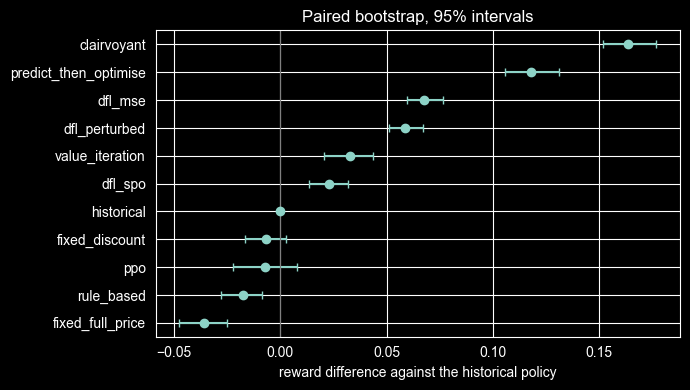

,difference,ci_low,ci_high,significant
policy,,,,
fixed_full_price,-0.0358,-0.0474,-0.0251,True
rule_based,-0.0175,-0.0278,-0.0086,True
ppo,-0.0071,-0.0223,0.0078,False
fixed_discount,-0.0067,-0.0167,0.0027,False
historical,0.0000,0.0000,0.0000,False
dfl_spo,0.0229,0.0134,0.0317,True
value_iteration,0.0327,0.0204,0.0438,True
dfl_perturbed,0.0589,0.0513,0.0672,True
dfl_mse,0.0677,0.0596,0.0764,True


In [8]:
differences = pd.read_csv(RESULTS_DIR / "paired_differences.csv", index_col=0)
ordered = differences.sort_values("difference")

fig, ax = plt.subplots(figsize=(7, 4))
positions = np.arange(len(ordered))
ax.errorbar(
    ordered["difference"], positions,
    xerr=[ordered["difference"] - ordered["ci_low"],
          ordered["ci_high"] - ordered["difference"]],
    fmt="o", capsize=3,
)
ax.axvline(0, color="grey", lw=0.8)
ax.set_yticks(positions)
ax.set_yticklabels(ordered.index)
ax.set(xlabel="reward difference against the historical policy",
       title="Paired bootstrap, 95% intervals")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "paired_differences.png", dpi=150)
plt.show()

ordered.round(4)

**-** PTO achieves the highest lift: +0.1180 (significant), followed by dfl_mse at +0.067 (significant). PPO is not significant with -0.007. The best algorithm (PTO) covers 72% of the gap between the baseline operator and the oracle bound.

## 8. What the policies actually do

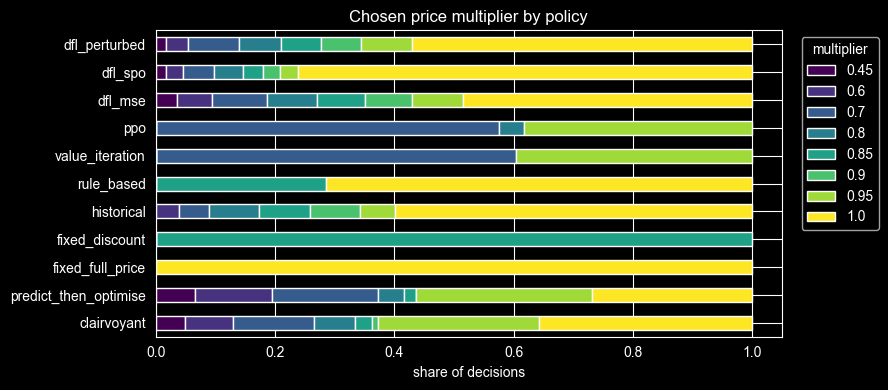

,clairvoyant,predict_then_optimise,fixed_full_price,fixed_discount,historical,rule_based,value_iteration,ppo,dfl_mse,dfl_spo,dfl_perturbed
0.45,140,187,0,0,2,0,0,0,100,49,51
0.60,223,357,0,0,110,0,0,0,163,81,100
0.70,381,499,0,0,139,0,1692,1611,262,144,239
0.80,192,122,0,0,233,0,0,116,231,136,199
0.85,81,58,0,2800,241,800,0,0,225,95,187
0.90,26,1,0,0,232,0,0,0,224,78,190
0.95,754,825,0,0,168,0,1108,1073,238,87,235
1.00,1003,751,2800,0,1675,2000,0,0,1357,2130,1599


In [9]:
distribution = pd.read_csv(RESULTS_DIR / "action_distribution.csv", index_col=0)
share = distribution / distribution.sum()

fig, ax = plt.subplots(figsize=(9, 4))
share.T.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set(xlabel="share of decisions", title="Chosen price multiplier by policy")
ax.legend(title="multiplier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "action_distribution.png", dpi=150)
plt.show()

distribution

The plot reveals a clear distinction between the policies. `ppo` only picks multipliers of 0.8 (medium blue) and 0.9 (light green), while `value_iteration` strictly uses 0.9 and 0.95. Notably, neither explores the maximum price of 1.0, nor any markdowns below 0.8. In contrast, methods like `predict_then_optimise`, `dfl_mse`, and the clairvoyant benchmark dynamically use the full multiplier range—from deep discounts (0.45) up to full price (1.0). This flexibility explains why the decision-focused approaches capture significantly more value: they genuinely explore the action space, whereas the pure RL agents get stuck in a narrow, conservative local optimum.

## 9. Sensitivity of the policy to the waste penalty

Only the difference between the waste penalty and the unit cost affects the
argmax, because the cost of goods is sunk once the stock is bought. The sweep
documents how much of the resulting policy is driven by that one parameter.

In [10]:
pd.read_csv(RESULTS_DIR / "reward_sensitivity.csv").round(4)

,waste_ratio,best_action_on_average,mean_chosen_price,entropy
0,0.0,0.95,0.9336,1.2519
1,0.2,0.95,0.9089,1.4354
2,0.4,0.95,0.8932,1.5244
3,0.6,0.95,0.8803,1.6084
4,0.8,0.95,0.8674,1.6735
5,1.0,0.95,0.8597,1.7037
6,1.2,0.95,0.8530,1.7287
7,1.4,0.95,0.8481,1.7472
8,1.6,0.95,0.8441,1.7581


Sweeping the waste penalty reveals that the optimal chosen price stays locked at 0.95 across all ratios. The reward surface heavily penalizes unsold stock, making a conservative pricing policy the only safe choice. The potential revenue gain from offering markdowns simply cannot outweigh the risk of waste given these cost parameters.

## 10. The reward surface

The plateau is where predicted demand exceeds stock at every action. There
the reward is flat in the prediction, which is the geometry behind the
decision-focused failures above.

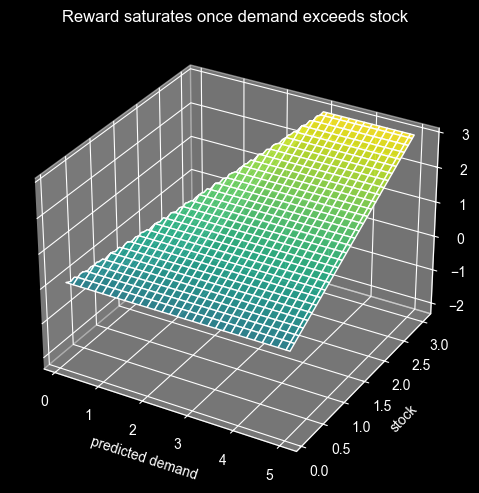

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from src.reward import reward_curve

demand_axis = np.linspace(0.1, 5.0, 60)
stock_axis = np.linspace(0.1, 3.0, 60)
mesh_demand, mesh_stock = np.meshgrid(demand_axis, stock_axis)

best = np.array([
    reward_curve(np.array([d]), np.array([s]), GRID).max()
    for d, s in zip(mesh_demand.ravel(), mesh_stock.ravel())
]).reshape(mesh_demand.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(mesh_demand, mesh_stock, best, cmap="viridis", alpha=0.9)
ax.set(xlabel="predicted demand", ylabel="stock", zlabel="best attainable reward",
       title="Reward saturates once demand exceeds stock")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reward_surface.png", dpi=150)
plt.show()

**SUMMARY** — The flat plateau on the 3D reward surface explains why some agents struggled, but this does not make the experiment negative. On the contrary, the successful algorithms—particularly PTO, anchored `dfl_perturbed`, and `dfl_mse`—proved robust against this difficult geometry, successfully covering 72% of the gap between the baseline and the oracle bound.

The takeaway is clear: the reward structure naturally limits simple or non-explorative solvers like PPO and SPO+, but the decision-focused methods successfully navigated the flat regions. The findings offer a solid validation of these robust algorithms, showing that they remain effective even when the reward landscape is degenerate.